In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All Libraries Imported Successfully!")

All Libraries Imported Successfully!


Loading Dataset from Drive

In [ ]:
# Load dataset directly from Google Drive
file_id = "1-IWl0EO5WjOvtuXTL2JACA4BiG9feyjd"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_csv(url)
print("Dataset Loaded Successfully! ")
print("Shape:", df.shape)

Dataset Loaded Successfully! 
Shape: (1048, 10)


Exploring Dataset

In [ ]:
# See first 5 rows
print("First 5 rows:")
df.head()

First 5 rows:


,id,title,company,location,link,source,date_posted,work_type,employment_type,description
0,1,Data Analyst,Meta,"New York, NY",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...
1,2,Data Analyst,Meta,"San Francisco, CA",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...
2,3,Data Analyst,Meta,"Los Angeles, CA",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...
3,4,Data Analyst,Meta,"Washington, DC",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...
4,5,Data Analyst II,Pinterest,"Chicago, IL",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-16,NaN,NaN,About Pinterest\n\nMillions of people around t...


In [ ]:
# Check basic info
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (1048, 10)

Column Names:
['id', 'title', 'company', 'location', 'link', 'source', 'date_posted', 'work_type', 'employment_type', 'description']

Data Types:
id                   int64
title               object
company             object
location            object
link                object
source              object
date_posted         object
work_type          float64
employment_type    float64
description         object
dtype: object

Missing Values:
id                    0
title                 0
company               2
location             15
link                  0
source               89
date_posted          23
work_type          1048
employment_type    1048
description           4
dtype: int64


In [ ]:
# Basic statistics
df.describe()

,id,work_type,employment_type
count,1048.000000,0.0,0.0
mean,1314.083969,NaN,NaN
std,772.822422,NaN,NaN
min,1.000000,NaN,NaN
25%,616.750000,NaN,NaN
50%,1303.500000,NaN,NaN
75%,2033.250000,NaN,NaN
max,2534.000000,NaN,NaN


Cleaning the Data

In [ ]:
df = df.drop(columns=['work_type', 'employment_type', 'link', 'id'])
print("Useless columns dropped! ")

Useless columns dropped! 


In [ ]:
df = df.dropna(subset=['company', 'location', 'date_posted'])
print("Missing rows dropped! ")
print("New Shape:", df.shape)

Missing rows dropped! 
New Shape: (1012, 6)


In [ ]:
df['source'] = df['source'].fillna('LinkedIn')

df['description'] = df['description'].fillna('No Description')

print("Missing values filled! ")
print("Total Missing Values:", df.isnull().sum().sum())

Missing values filled! 
Total Missing Values: 0


Visualizations

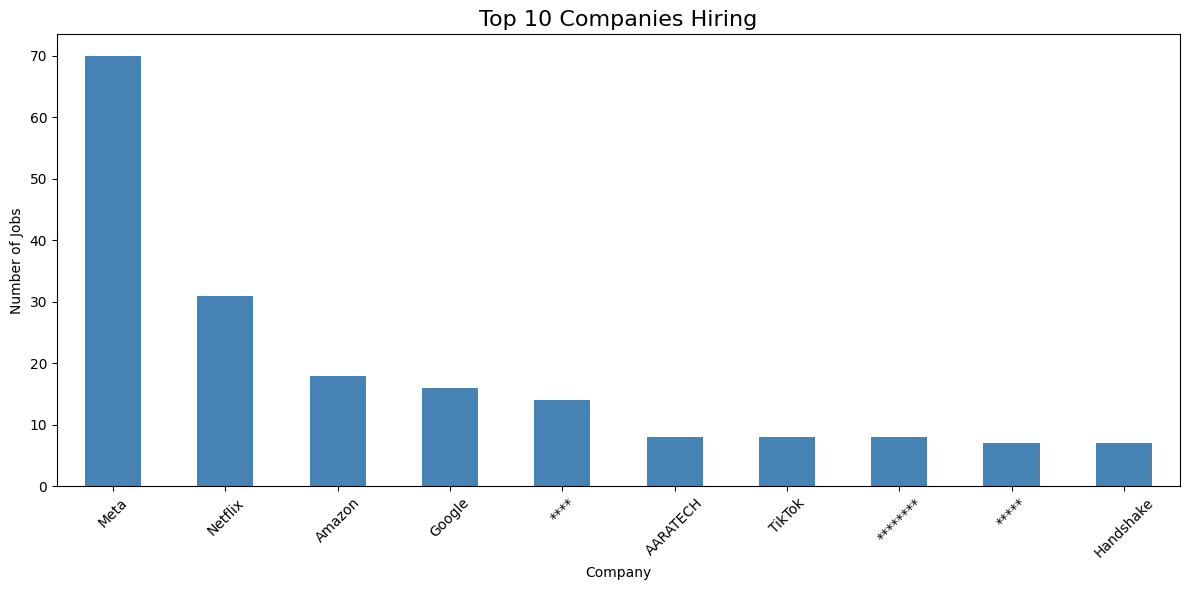

In [ ]:
# Chart 1 - Top 10 Companies Hiring
# This shows which companies have most job openings
plt.figure(figsize=(12,6))
df['company'].value_counts().head(10).plot(kind='bar',
                                            color='steelblue')
plt.title("Top 10 Companies Hiring", fontsize=16)
plt.xlabel("Company")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

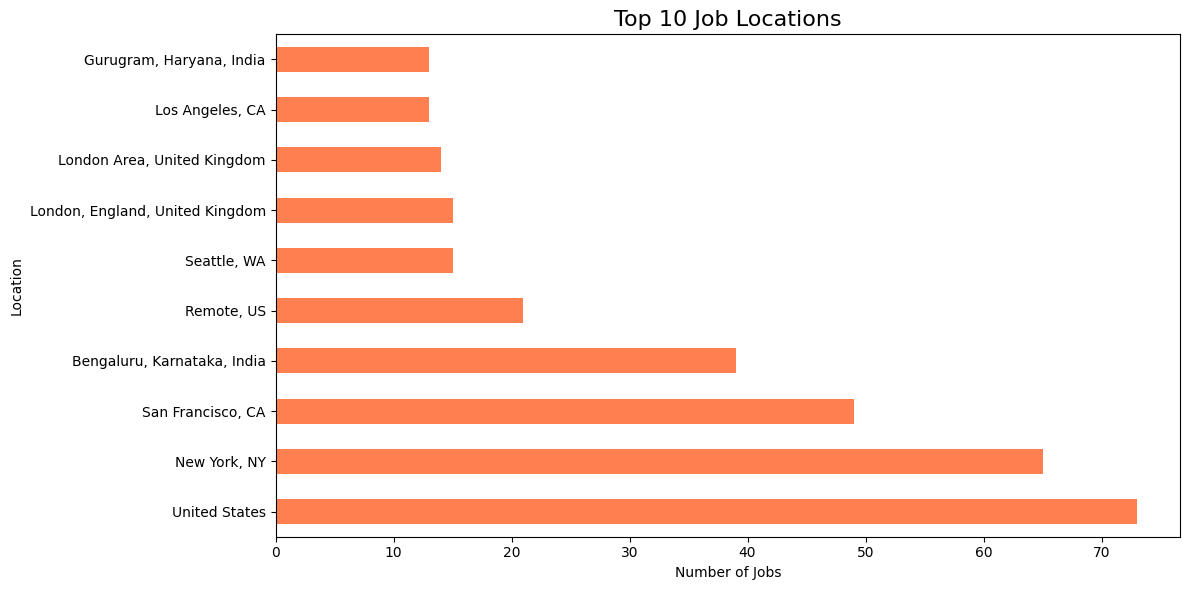

In [ ]:
# Chart 2 - Top 10 Job Locations
# This shows which cities have most data science jobs
plt.figure(figsize=(12,6))
df['location'].value_counts().head(10).plot(kind='barh',
                                             color='coral')
plt.title("Top 10 Job Locations", fontsize=16)
plt.xlabel("Number of Jobs")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

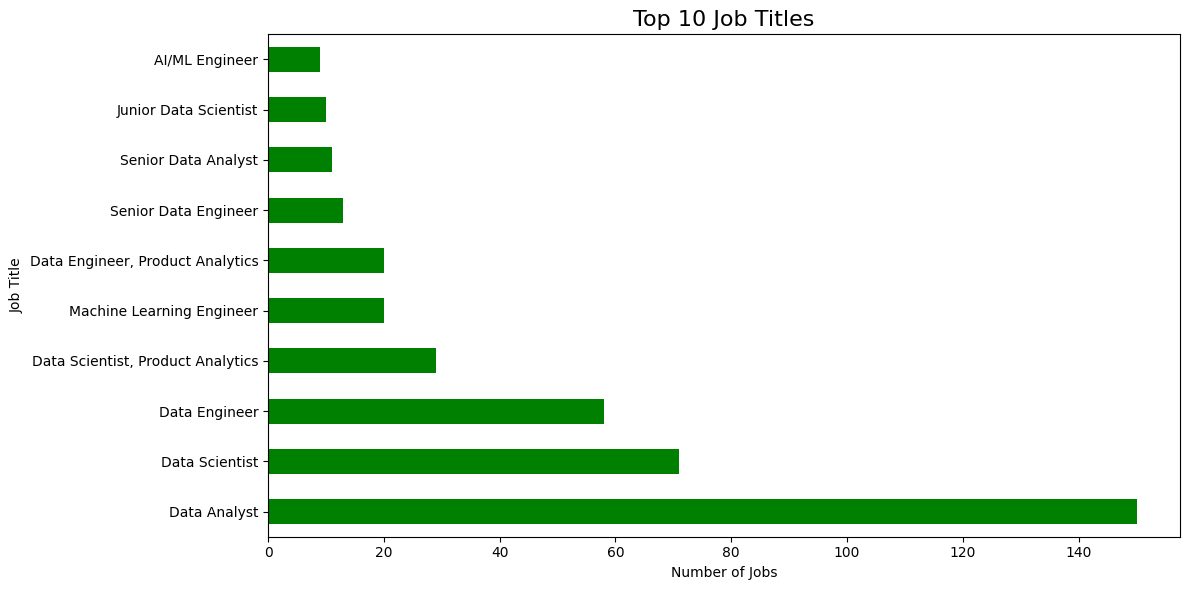

In [ ]:
# Chart 3 - Top 10 Job Titles
# This shows most in-demand data science roles
plt.figure(figsize=(12,6))
df['title'].value_counts().head(10).plot(kind='barh',
                                          color='green')
plt.title("Top 10 Job Titles", fontsize=16)
plt.xlabel("Number of Jobs")
plt.ylabel("Job Title")
plt.tight_layout()
plt.show()

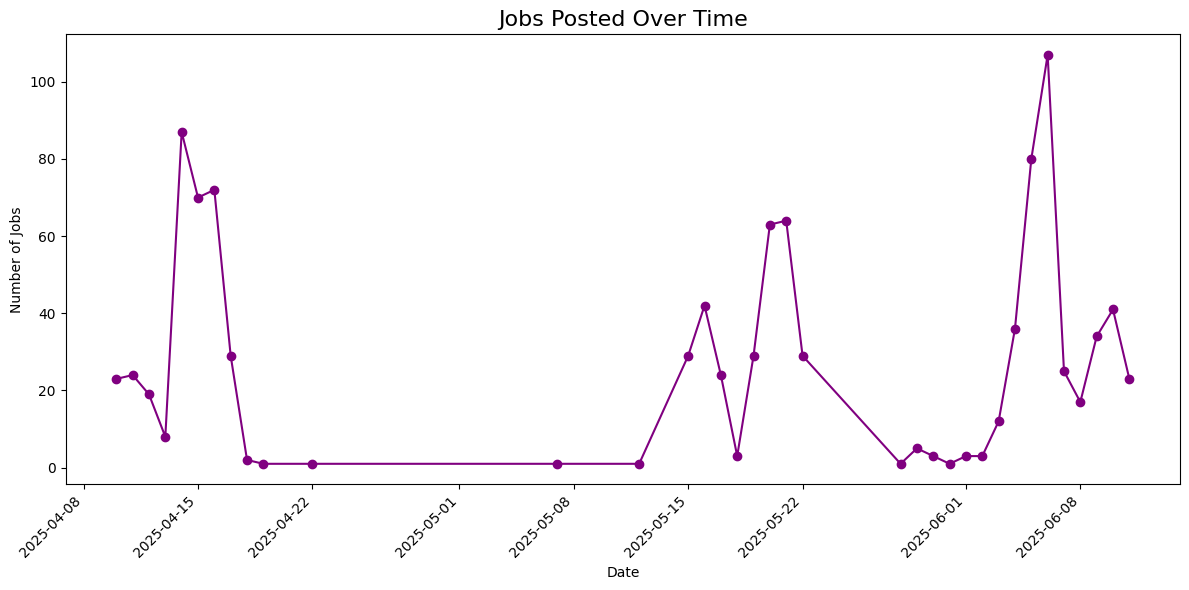

In [ ]:
# Chart 4 - Jobs Posted Over Time
# This shows how many jobs were posted each day
# First convert date_posted to datetime format
df['date_posted'] = pd.to_datetime(df['date_posted'])

plt.figure(figsize=(12,6))
df.groupby('date_posted')['title'].count().plot(kind='line',
                                                  color='purple',
                                                  marker='o')
plt.title("Jobs Posted Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

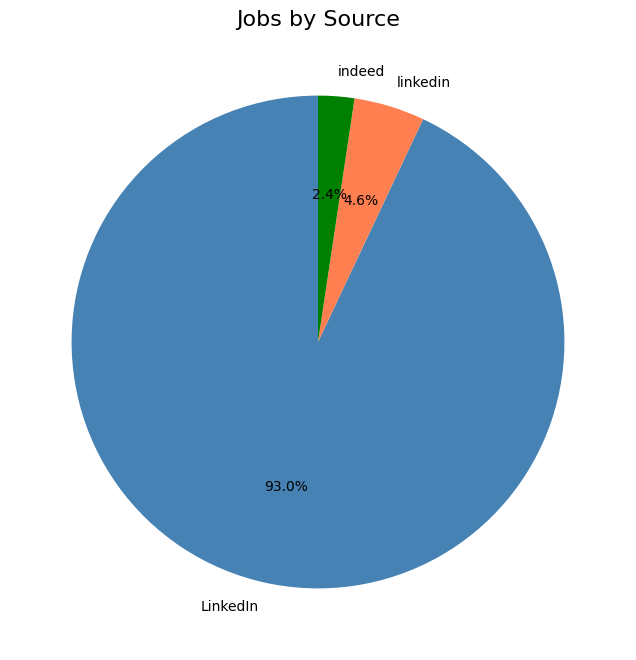

In [ ]:
# Chart 5 - Jobs by Source
# This shows which platform has most job postings
plt.figure(figsize=(8,8))
df['source'].value_counts().plot(kind='pie',
                                  autopct='%1.1f%%',
                                  colors=['steelblue','coral','green'],
                                  startangle=90)
plt.title("Jobs by Source", fontsize=16)
plt.ylabel("")
plt.show()

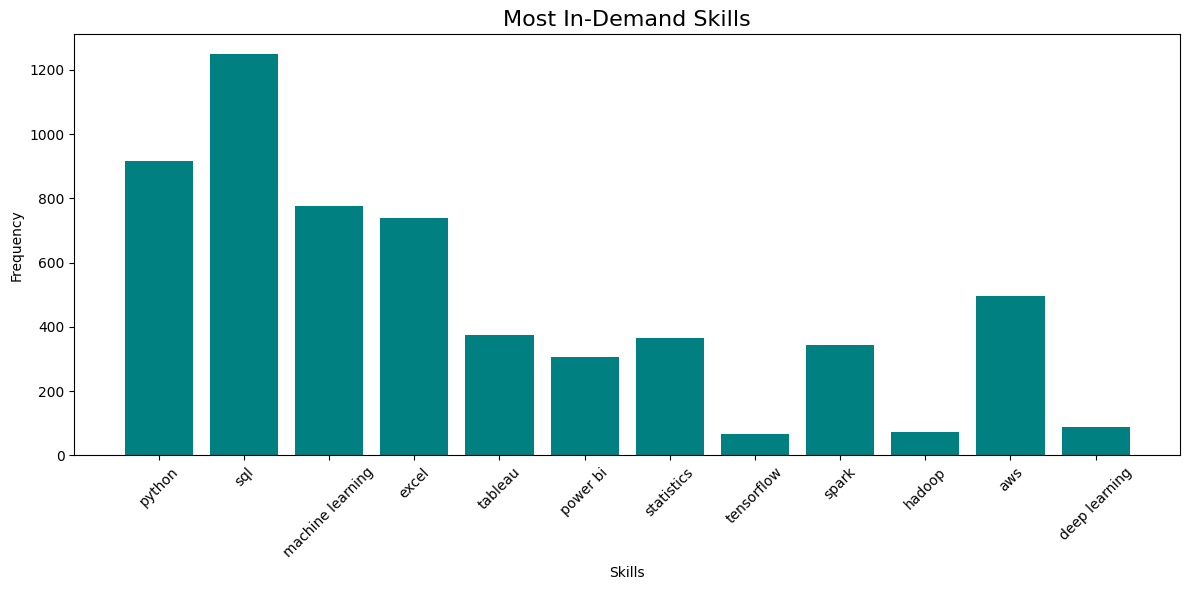

In [ ]:
# Chart 6 Fixed - Most Common Keywords
# Removed 'r ' because it matches every word with 'r'
keywords = ['python', 'sql', 'machine learning',
            'excel', 'tableau', 'power bi',
            'statistics', 'tensorflow',
            'spark', 'hadoop', 'aws', 'deep learning']

# Count each keyword
keyword_counts = {}
for keyword in keywords:
    count = all_text.lower().count(keyword.lower())
    keyword_counts[keyword] = count

# Plot
plt.figure(figsize=(12,6))
plt.bar(keyword_counts.keys(),
        keyword_counts.values(),
        color='teal')
plt.title("Most In-Demand Skills", fontsize=16)
plt.xlabel("Skills")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Conclusion

In [ ]:
# Project Conclusion
print("""
===========================================
   LINKEDIN JOB POSTINGS EDA
   CONCLUSION
===========================================

1. DATASET OVERVIEW:
   - Total Job Postings Analyzed: 1,012
   - Columns: 6
   - Source: LinkedIn, Indeed

2. DATA CLEANING:
   - Dropped 2 fully empty columns
   - Removed 36 rows with missing values
   - Zero missing values after cleaning

3. KEY INSIGHTS:

   TOP COMPANIES HIRING:
   - Meta is #1 with 70 job postings
   - Netflix, Amazon, Google follow

   TOP LOCATIONS:
   - United States has most jobs
   - New York and San Francisco lead
   - Bengaluru, India is top Indian city!

   TOP JOB ROLES:
   - Data Analyst is most in demand!
   - Data Scientist is 2nd most wanted
   - Data Engineer is 3rd

   TOP SKILLS:
   - SQL is most demanded skill
   - Python is 2nd most important
   - Machine Learning is 3rd

   HIRING TRENDS:
   - Hiring comes in waves
   - Peak hiring in June 2025

4. CONCLUSION:
   - LinkedIn dominates job market at 93%
   - SQL and Python are must-have skills
   - Data Analyst is hottest job in market!
   - India has strong Data Science market!
===========================================
""")


   LINKEDIN JOB POSTINGS EDA
   CONCLUSION

1. DATASET OVERVIEW:
   - Total Job Postings Analyzed: 1,012
   - Columns: 6
   - Source: LinkedIn, Indeed

2. DATA CLEANING:
   - Dropped 2 fully empty columns
   - Removed 36 rows with missing values
   - Zero missing values after cleaning

3. KEY INSIGHTS:

   TOP COMPANIES HIRING:
   - Meta is #1 with 70 job postings
   - Netflix, Amazon, Google follow

   TOP LOCATIONS:
   - United States has most jobs
   - New York and San Francisco lead
   - Bengaluru, India is top Indian city!

   TOP JOB ROLES:
   - Data Analyst is most in demand!
   - Data Scientist is 2nd most wanted
   - Data Engineer is 3rd

   TOP SKILLS:
   - SQL is most demanded skill
   - Python is 2nd most important
   - Machine Learning is 3rd

   HIRING TRENDS:
   - Hiring comes in waves
   - Peak hiring in June 2025

4. CONCLUSION:
   - LinkedIn dominates job market at 93%
   - SQL and Python are must-have skills
   - Data Analyst is hottest job in market!
   - India has